# Full Pipeline Test - Stage 3 Extraction

Test từng bước của pipeline với **3 loại chart** (BAR, LINE, PIE) có ground truth.

**Supported Chart Types:**
| Type | Key Component | Ground Truth |
|------|---------------|--------------|
| BAR | Element Detection (bars) | x_labels, y_values |
| LINE | Skeletonization + Vectorization | data points along line |
| PIE | Element Detection (slices) | labels, percentages |

**Steps:**
1. Setup & Check GPU
2. Create synthetic charts (all 3 types with ground truth)
3. Preprocessing
4. OCR Extraction
5. Element Detection
   - 5a. Bar/Marker Detection
   - 5b. Skeletonization (best for LINE charts)
   - 5c. Vectorization (best for LINE charts)
   - 5d. Geometric Mapping (pixel→value)
6. Axis Calibration
7. Final Output & Evaluation

**Change `CURRENT_CHART` to test different chart types:** `'bar'`, `'line'`, or `'pie'`

## Step 0: Setup & GPU Check

In [43]:
# Restart kernel before running this cell if you encounter DLL errors
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from PIL import Image
import io
import json

print('=== ENVIRONMENT CHECK ===')

# Check PaddlePaddle GPU
print('\n[PaddlePaddle]')
try:
    import paddle
    print(f'  Version: {paddle.__version__}')
    print(f'  CUDA compiled: {paddle.device.is_compiled_with_cuda()}')
except Exception as e:
    print(f'  Error: {e}')

# Check PyTorch GPU (for ResNet classifier)
print('\n[PyTorch]')
try:
    import torch
    print(f'  Version: {torch.__version__}')
    print(f'  CUDA available: {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'  CUDA device: {torch.cuda.get_device_name(0)}')
except Exception as e:
    print(f'  Error loading PyTorch: {e}')
    print('  NOTE: If DLL error, restart kernel and try again')

print('\n[OpenCV]')
print(f'  Version: {cv2.__version__}')

=== ENVIRONMENT CHECK ===

[PaddlePaddle]
  Version: 2.6.2
  CUDA compiled: False

[PyTorch]
  Error loading PyTorch: [WinError 127] The specified procedure could not be found. Error loading "d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.
  NOTE: If DLL error, restart kernel and try again

[OpenCV]
  Version: 4.13.0


## Step 1: Create Synthetic Chart (Ground Truth)

In [65]:
# === GROUND TRUTH DATA FOR ALL 3 CHART TYPES ===

CHART_CONFIGS = {
    'bar': {
        'chart_type': 'bar',
        'title': 'Monthly Sales 2025',
        'x_label': 'Month',
        'y_label': 'Revenue (USD)',
        'x_values': ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
        'y_values': [1200, 1800, 1500, 2200, 1900],
        'bar_color': '#4472C4',
    },
    'line': {
        'chart_type': 'line',
        'title': 'Temperature Trend 2025',
        'x_label': 'Month',
        'y_label': 'Temperature (C)',
        'x_values': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
        'y_values': [5, 8, 15, 22, 28, 32],
        'line_color': '#E74C3C',
        'marker': 'o',
    },
    'pie': {
        'chart_type': 'pie',
        'title': 'Market Share 2025',
        'labels': ['Product A', 'Product B', 'Product C', 'Product D'],
        'values': [35, 25, 22, 18],
        'colors': ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12'],
    },
}

# ========================================
# CHANGE THIS TO TEST DIFFERENT CHARTS
# ========================================
CURRENT_CHART = 'line'  # 'bar', 'line', or 'pie'
# ========================================

GROUND_TRUTH = CHART_CONFIGS[CURRENT_CHART]

print(f'=== GROUND TRUTH ({CURRENT_CHART.upper()} CHART) ===')
for k, v in GROUND_TRUTH.items():
    print(f'  {k}: {v}')

=== GROUND TRUTH (LINE CHART) ===
  chart_type: line
  title: Temperature Trend 2025
  x_label: Month
  y_label: Temperature (C)
  x_values: ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
  y_values: [5, 8, 15, 22, 28, 32]
  line_color: #E74C3C
  marker: o


Created bar: (552, 863, 3)
Created line: (552, 845, 3)
Created pie: (682, 794, 3)

=== CURRENT TEST: LINE ===


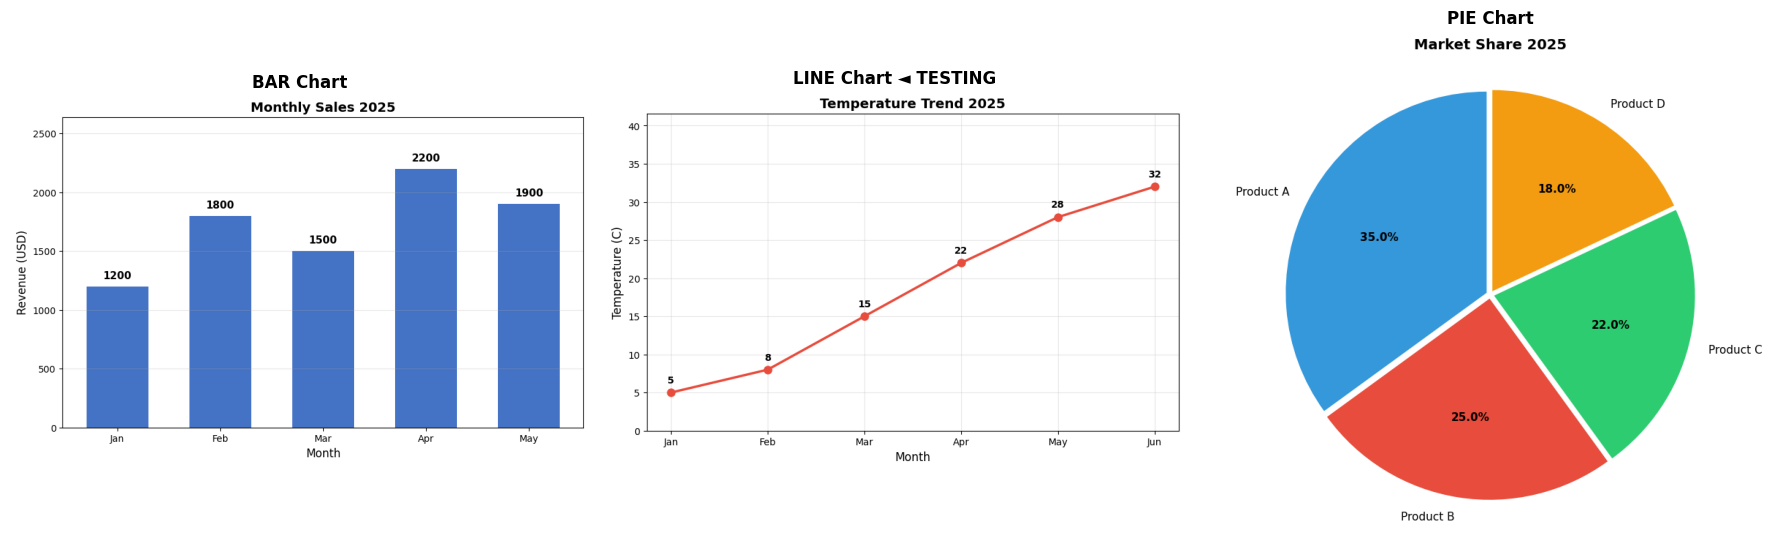

In [66]:
# === CHART GENERATION FUNCTIONS ===

def create_bar_chart(data: dict) -> np.ndarray:
    """Create bar chart and return as BGR numpy array."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    
    x = np.arange(len(data['x_values']))
    bars = ax.bar(x, data['y_values'], color=data['bar_color'], width=0.6)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, data['y_values']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xlabel(data['x_label'], fontsize=12)
    ax.set_ylabel(data['y_label'], fontsize=12)
    ax.set_title(data['title'], fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(data['x_values'])
    ax.set_ylim(0, max(data['y_values']) * 1.2)
    ax.yaxis.grid(True, alpha=0.3)
    
    return _fig_to_bgr(fig)


def create_line_chart(data: dict) -> np.ndarray:
    """Create line chart and return as BGR numpy array."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    
    x = np.arange(len(data['x_values']))
    ax.plot(x, data['y_values'], color=data['line_color'], 
            marker=data.get('marker', 'o'), markersize=8, linewidth=2.5)
    
    # Add value labels at each point
    for i, val in enumerate(data['y_values']):
        ax.annotate(str(val), (i, val), textcoords="offset points", 
                   xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel(data['x_label'], fontsize=12)
    ax.set_ylabel(data['y_label'], fontsize=12)
    ax.set_title(data['title'], fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(data['x_values'])
    ax.set_ylim(0, max(data['y_values']) * 1.3)
    ax.yaxis.grid(True, alpha=0.3)
    ax.xaxis.grid(True, alpha=0.3)
    
    return _fig_to_bgr(fig)


def create_pie_chart(data: dict) -> np.ndarray:
    """Create pie chart and return as BGR numpy array."""
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    
    wedges, texts, autotexts = ax.pie(
        data['values'], 
        labels=data['labels'],
        colors=data['colors'],
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.02] * len(data['values']),
        textprops={'fontsize': 11}
    )
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_fontweight('bold')
    
    ax.set_title(data['title'], fontsize=14, fontweight='bold', pad=20)
    ax.axis('equal')
    
    return _fig_to_bgr(fig)


def _fig_to_bgr(fig) -> np.ndarray:
    """Convert matplotlib figure to BGR numpy array."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor='white', edgecolor='none')
    buf.seek(0)
    img = Image.open(buf)
    img_array = np.array(img)
    plt.close(fig)
    
    if img_array.shape[-1] == 4:
        return cv2.cvtColor(img_array, cv2.COLOR_RGBA2BGR)
    return cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)


# === CREATE ALL 3 CHARTS ===
chart_images = {}
for chart_type, config in CHART_CONFIGS.items():
    if chart_type == 'bar':
        chart_images[chart_type] = create_bar_chart(config)
    elif chart_type == 'line':
        chart_images[chart_type] = create_line_chart(config)
    elif chart_type == 'pie':
        chart_images[chart_type] = create_pie_chart(config)
    
    # Save each chart
    save_path = Path(f'../data/samples/test_{chart_type}_chart.png')
    save_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(save_path), chart_images[chart_type])
    print(f'Created {chart_type}: {chart_images[chart_type].shape}')

# Set current test image
test_image = chart_images[CURRENT_CHART]
print(f'\n=== CURRENT TEST: {CURRENT_CHART.upper()} ===')

# Display all 3 charts side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (chart_type, img) in zip(axes, chart_images.items()):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    marker = ' ◄ TESTING' if chart_type == CURRENT_CHART else ''
    ax.set_title(f'{chart_type.upper()} Chart{marker}', fontsize=12, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 2: Preprocessing

=== PREPROCESSING ===
Original size: (552, 845)
Binary shape: (552, 845)
Cleaned shape: (552, 845)
Operations: ['bgr_to_grayscale', 'denoise', 'negative_transform', 'white_tophat', 'adaptive_threshold', 'grid_removal', 'noise_filtering']


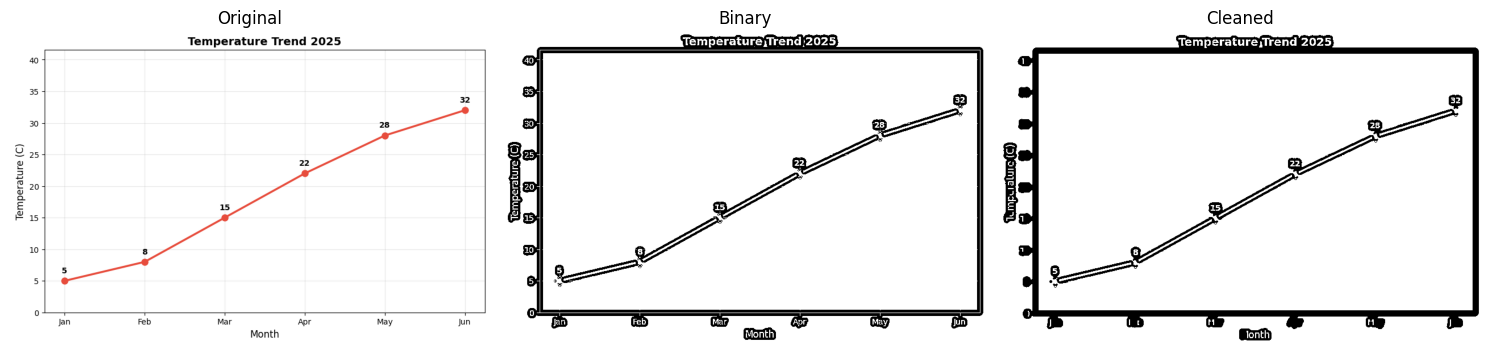

In [67]:
# Workaround: Import directly to avoid PyTorch DLL issue in Jupyter

import sys
sys.path.insert(0, '../src')

# Direct import of preprocessor without going through __init__.py chain
import importlib.util
spec = importlib.util.spec_from_file_location(
    "preprocessor", 
    "../src/core_engine/stages/s3_extraction/preprocessor.py"
)
preprocessor_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(preprocessor_module)

Preprocessor = preprocessor_module.ImagePreprocessor
PreprocessConfig = preprocessor_module.PreprocessConfig

# Initialize preprocessor
preprocess_config = PreprocessConfig()
preprocessor = Preprocessor(preprocess_config)

print('=== PREPROCESSING ===')
preprocess_result = preprocessor.process(test_image, chart_id='test_001')

print(f'Original size: {test_image.shape[:2]}')
print(f'Binary shape: {preprocess_result.binary_image.shape}')
print(f'Cleaned shape: {preprocess_result.cleaned_image.shape}')
print(f'Operations: {preprocess_result.operations_applied}')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(preprocess_result.binary_image, cmap='gray')
axes[1].set_title('Binary')
axes[1].axis('off')

axes[2].imshow(preprocess_result.cleaned_image, cmap='gray')
axes[2].set_title('Cleaned')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Step 3: OCR Extraction

In [47]:
# OCR Extraction - Using PaddleOCR directly (bypass import chain issues)
# This is a workaround for PyTorch DLL loading issue in Jupyter kernel

from paddleocr import PaddleOCR
from dataclasses import dataclass
from typing import List, Optional
from enum import Enum

# Define minimal classes needed
class TextRole(str, Enum):
    TITLE = "title"
    X_LABEL = "x_label" 
    Y_LABEL = "y_label"
    X_TICK = "x_tick"
    Y_TICK = "y_tick"
    DATA_LABEL = "data_label"
    LEGEND = "legend"
    X_AXIS_LABEL = "x_axis_label"
    Y_AXIS_LABEL = "y_axis_label"
    UNKNOWN = "unknown"

@dataclass
class SimpleBBox:
    x_min: int
    y_min: int
    x_max: int
    y_max: int
    confidence: float = 1.0

@dataclass  
class SimpleOCRText:
    text: str
    bbox: SimpleBBox
    confidence: float
    role: TextRole = TextRole.UNKNOWN

@dataclass
class SimpleOCRResult:
    texts: List[SimpleOCRText]
    mean_confidence: float

def classify_role(text: str, bbox: SimpleBBox, img_h: int, img_w: int) -> TextRole:
    """Simple heuristic role classification."""
    text_lower = text.lower().strip()
    cx = (bbox.x_min + bbox.x_max) / 2
    cy = (bbox.y_min + bbox.y_max) / 2
    
    # Title: top center
    if cy < img_h * 0.15 and 0.2 < cx/img_w < 0.8:
        return TextRole.TITLE
    
    # Y-axis label: left side, rotated text (narrow bbox)
    if cx < img_w * 0.12:
        if bbox.x_max - bbox.x_min < 50:  # narrow = rotated
            return TextRole.Y_AXIS_LABEL
        return TextRole.Y_TICK
    
    # X-axis ticks: bottom area
    if cy > img_h * 0.85:
        return TextRole.X_TICK
    
    # Data labels: numeric values in chart area
    try:
        float(text.replace(',', '').replace('%', ''))
        if 0.1 < cx/img_w < 0.9 and 0.2 < cy/img_h < 0.8:
            return TextRole.DATA_LABEL
    except:
        pass
    
    # Y-ticks: left side numbers
    if cx < img_w * 0.15:
        try:
            float(text.replace(',', ''))
            return TextRole.Y_TICK
        except:
            pass
    
    return TextRole.UNKNOWN

# Initialize PaddleOCR
print('Initializing PaddleOCR...')
ocr = PaddleOCR(use_angle_cls=False, lang='en', show_log=False)

# Run OCR
print('Running OCR on test image...')
result = ocr.ocr(test_image, cls=False)

# Parse results
texts = []
img_h, img_w = test_image.shape[:2]

if result and result[0]:
    for line in result[0]:
        bbox_pts, (text, conf) = line
        # Convert polygon to bbox
        xs = [p[0] for p in bbox_pts]
        ys = [p[1] for p in bbox_pts]
        bbox = SimpleBBox(
            x_min=int(min(xs)),
            y_min=int(min(ys)),
            x_max=int(max(xs)),
            y_max=int(max(ys)),
            confidence=conf
        )
        role = classify_role(text, bbox, img_h, img_w)
        texts.append(SimpleOCRText(text=text, bbox=bbox, confidence=conf, role=role))

mean_conf = sum(t.confidence for t in texts) / len(texts) if texts else 0
ocr_result = SimpleOCRResult(texts=texts, mean_confidence=mean_conf)

print('=== OCR EXTRACTION ===')
print(f'Texts found: {len(ocr_result.texts)}')
print(f'Mean confidence: {ocr_result.mean_confidence:.2%}')
print()

# Print detected texts
print('Detected texts:')
print(f'{"#":<3} {"Role":<12} {"Conf":>6} {"Text"}')
print('-' * 50)
for i, t in enumerate(ocr_result.texts):
    print(f'{i+1:<3} {t.role.value:<12} {t.confidence:>6.2%} "{t.text}"')

Initializing PaddleOCR...
Running OCR on test image...
=== OCR EXTRACTION ===
Texts found: 20
Mean confidence: 96.36%

Detected texts:
#   Role           Conf Text
--------------------------------------------------
1   title        98.79% "Monthly Sales 2025"
2   y_axis_label 99.95% "2500"
3   unknown      99.95% "2200"
4   y_axis_label 99.93% "2000"
5   data_label   99.97% "1900"
6   data_label   99.95% "1800"
7   y_axis_label 94.63% "(asn)"
8   data_label   99.98% "1500"
9   y_axis_label 99.95% "1500"
10  y_axis_label 59.70% "Rrnnne"
11  data_label   99.96% "1200"
12  y_axis_label 99.94% "1000"
13  y_axis_label 99.93% "500"
14  y_axis_label 75.40% "0"
15  x_tick       99.77% "Jan"
16  x_tick       99.85% "Feb"
17  x_tick       99.91% "Mar"
18  x_tick       99.98% "Apr"
19  x_tick       99.72% "May"
20  x_tick       99.90% "Month"


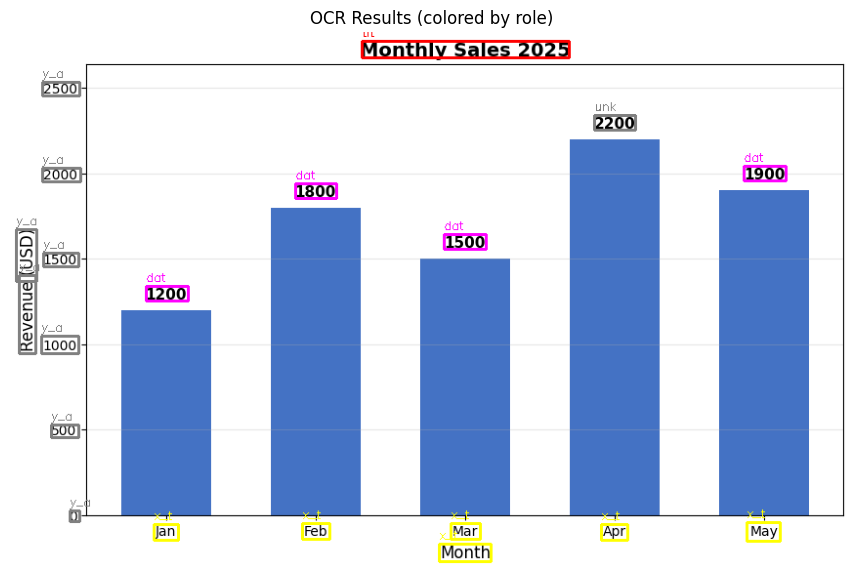

Legend: Red=title, Green=x_label, Blue=y_label, Yellow=x_tick, Cyan=y_tick, Magenta=data_label


In [48]:
# Visualize OCR results
def visualize_ocr(image: np.ndarray, ocr_result):
    vis = image.copy()
    
    # Color by role
    role_colors = {
        'title': (0, 0, 255),      # Red
        'x_label': (0, 255, 0),    # Green
        'y_label': (255, 0, 0),    # Blue
        'x_tick': (0, 255, 255),   # Yellow
        'y_tick': (255, 255, 0),   # Cyan
        'data_label': (255, 0, 255), # Magenta
        'legend': (128, 128, 0),   # Olive
    }
    
    for t in ocr_result.texts:
        if t.bbox:
            role = t.role.value if hasattr(t.role, 'value') else 'unknown'
            color = role_colors.get(role, (128, 128, 128))
            
            cv2.rectangle(vis,
                         (t.bbox.x_min, t.bbox.y_min),
                         (t.bbox.x_max, t.bbox.y_max),
                         color, 2)
            
            # Add label
            cv2.putText(vis, f'{role[:3]}', 
                       (t.bbox.x_min, t.bbox.y_min - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    
    return vis

ocr_vis = visualize_ocr(test_image, ocr_result)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(ocr_vis, cv2.COLOR_BGR2RGB))
plt.title('OCR Results (colored by role)')
plt.axis('off')
plt.show()

print('Legend: Red=title, Green=x_label, Blue=y_label, Yellow=x_tick, Cyan=y_tick, Magenta=data_label')

In [49]:
# Compare with ground truth
print('=== OCR vs GROUND TRUTH ===')

detected_texts = [t.text for t in ocr_result.texts]

# Check title
title_found = any(GROUND_TRUTH['title'].lower() in t.lower() for t in detected_texts)
print(f'Title "{GROUND_TRUTH["title"]}" found: {title_found}')

# Check x labels
x_labels_found = [lbl for lbl in GROUND_TRUTH['x_values'] if any(lbl.lower() in t.lower() for t in detected_texts)]
print(f'X labels found: {x_labels_found} / {GROUND_TRUTH["x_values"]}')

# Check y values
detected_nums = []
for t in detected_texts:
    try:
        num = int(t.replace(',', '').strip())
        detected_nums.append(num)
    except:
        pass

y_values_found = [v for v in GROUND_TRUTH['y_values'] if v in detected_nums]
print(f'Y values found: {y_values_found} / {GROUND_TRUTH["y_values"]}')

=== OCR vs GROUND TRUTH ===
Title "Monthly Sales 2025" found: True
X labels found: ['Jan', 'Feb', 'Mar', 'Apr', 'May'] / ['Jan', 'Feb', 'Mar', 'Apr', 'May']
Y values found: [1200, 1800, 1500, 2200, 1900] / [1200, 1800, 1500, 2200, 1900]


## Step 4: Element Detection

In [50]:
# Setup module hierarchy for direct imports (bypass PyTorch chain)
# This cell must run before any core_engine imports

import sys
import importlib.util
from pathlib import Path

# Define base paths
src_path = Path('../src').resolve()

def load_module_direct(name: str, filepath: str):
    """Load a Python module directly from file path."""
    spec = importlib.util.spec_from_file_location(name, filepath)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

# Load enums first (no dependencies)
schemas_enums = load_module_direct(
    'core_engine.schemas.enums',
    str(src_path / 'core_engine/schemas/enums.py')
)

# Inject into parent modules
class MockModule:
    pass

if 'core_engine' not in sys.modules:
    sys.modules['core_engine'] = MockModule()
if 'core_engine.schemas' not in sys.modules:
    sys.modules['core_engine.schemas'] = MockModule()

sys.modules['core_engine.schemas'].enums = schemas_enums

# Load common (depends on enums)
schemas_common = load_module_direct(
    'core_engine.schemas.common',
    str(src_path / 'core_engine/schemas/common.py')
)
sys.modules['core_engine.schemas'].common = schemas_common

# Load extraction (depends on common)
schemas_extraction = load_module_direct(
    'core_engine.schemas.extraction',
    str(src_path / 'core_engine/schemas/extraction.py')
)
sys.modules['core_engine.schemas'].extraction = schemas_extraction

# Load stage_outputs
schemas_stage_outputs = load_module_direct(
    'core_engine.schemas.stage_outputs',
    str(src_path / 'core_engine/schemas/stage_outputs.py')
)
sys.modules['core_engine.schemas'].stage_outputs = schemas_stage_outputs

# Setup stages mock
if 'core_engine.stages' not in sys.modules:
    sys.modules['core_engine.stages'] = MockModule()
if 'core_engine.stages.s3_extraction' not in sys.modules:
    sys.modules['core_engine.stages.s3_extraction'] = MockModule()

print('[OK] Module hierarchy setup complete')
print(f'  - Loaded: enums, common, extraction, stage_outputs')

[OK] Module hierarchy setup complete
  - Loaded: enums, common, extraction, stage_outputs


In [51]:
# Element Detection - Load module properly
from pathlib import Path
import importlib.util

src_path = Path('../src').resolve()

# Load element_detector as part of the package
elem_path = str(src_path / 'core_engine/stages/s3_extraction/element_detector.py')
spec = importlib.util.spec_from_file_location(
    "core_engine.stages.s3_extraction.element_detector",
    elem_path,
    submodule_search_locations=[str(src_path / 'core_engine/stages/s3_extraction')]
)
elem_module = importlib.util.module_from_spec(spec)

# Set __package__ to enable relative imports
elem_module.__package__ = 'core_engine.stages.s3_extraction'

# Register in sys.modules before exec
sys.modules['core_engine.stages.s3_extraction.element_detector'] = elem_module
spec.loader.exec_module(elem_module)

ElementDetector = elem_module.ElementDetector
ElementDetectorConfig = elem_module.ElementDetectorConfig

# Initialize
elem_config = ElementDetectorConfig()
element_detector = ElementDetector(elem_config)

print('=== ELEMENT DETECTION ===')
elem_result = element_detector.detect(
    preprocess_result.binary_image,
    test_image,
    chart_id='test_001',
    chart_type='bar'
)

print(f'Bars detected: {len(elem_result.bars)}')
print(f'Markers detected: {len(elem_result.markers)}')
print(f'Slices detected: {len(elem_result.slices)}')
print()

# Expected: 5 bars
print(f'Expected bars: {len(GROUND_TRUTH["y_values"])}')
print(f'Match: {len(elem_result.bars) == len(GROUND_TRUTH["y_values"])}')

=== ELEMENT DETECTION ===
Bars detected: 5
Markers detected: 1
Slices detected: 0

Expected bars: 5
Match: True


In [52]:
# Print bar details
print('=== DETECTED BARS ===')
print(f'{"#":<3} {"Center":>15} {"Size":>12} {"Area":>8} {"Color"}')
print('-' * 60)

for i, bar in enumerate(elem_result.bars):
    center = f'({bar.center.x:4.0f}, {bar.center.y:4.0f})'
    w = bar.x_max - bar.x_min
    h = bar.y_max - bar.y_min
    size = f'{w:3.0f} x {h:3.0f}'
    color = f'RGB({bar.color.r}, {bar.color.g}, {bar.color.b})' if bar.color else 'N/A'
    print(f'{i+1:<3} {center:>15} {size:>12} {bar.area:>8.0f} {color}')

=== DETECTED BARS ===
#            Center         Size     Area Color
------------------------------------------------------------
1      ( 162,  392)     92 x 210    19320 RGB(72, 117, 196)
2      ( 468,  366)     92 x 263    24196 RGB(72, 117, 196)
3      ( 315,  340)     92 x 315    28980 RGB(72, 117, 196)
4      ( 774,  330)     92 x 333    30636 RGB(72, 117, 196)
5      ( 621,  304)     92 x 385    35420 RGB(72, 117, 196)


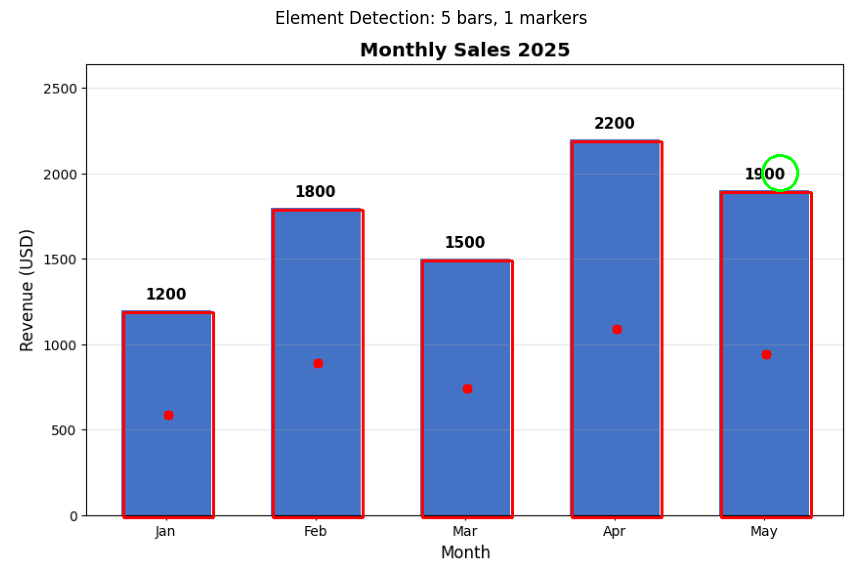

In [53]:
# Visualize elements
def visualize_elements(image: np.ndarray, elem_result):
    vis = image.copy()
    
    # Draw bars (red)
    for bar in elem_result.bars:
        cv2.rectangle(vis,
                     (int(bar.x_min), int(bar.y_min)),
                     (int(bar.x_max), int(bar.y_max)),
                     (0, 0, 255), 2)
        cv2.circle(vis, (int(bar.center.x), int(bar.center.y)), 5, (0, 0, 255), -1)
    
    # Draw markers (green)
    for m in elem_result.markers:
        cv2.circle(vis, (int(m.center.x), int(m.center.y)), int(m.size), (0, 255, 0), 2)
    
    return vis

elem_vis = visualize_elements(test_image, elem_result)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(elem_vis, cv2.COLOR_BGR2RGB))
plt.title(f'Element Detection: {len(elem_result.bars)} bars, {len(elem_result.markers)} markers')
plt.axis('off')
plt.show()

## Step 4b: Skeletonization (Line Charts)

Chuyển đổi ảnh binary thành skeleton (xương sống) cho line charts.
- Zhang-Suen thinning algorithm
- Stroke width estimation
- Branch point detection

In [68]:
# Skeletonization - Load module directly
skel_spec = importlib.util.spec_from_file_location(
    "core_engine.stages.s3_extraction.skeletonizer",
    str(src_path / 'core_engine/stages/s3_extraction/skeletonizer.py'),
)
skel_module = importlib.util.module_from_spec(skel_spec)
skel_module.__package__ = 'core_engine.stages.s3_extraction'
sys.modules['core_engine.stages.s3_extraction.skeletonizer'] = skel_module
skel_spec.loader.exec_module(skel_module)

Skeletonizer = skel_module.Skeletonizer
SkeletonConfig = skel_module.SkeletonConfig

# Initialize with default config
skel_config = SkeletonConfig()
skeletonizer = Skeletonizer(skel_config)

print('=== SKELETONIZATION ===')
print('(Best suited for LINE charts - bar charts may have limited skeleton)')
print()

# Run skeletonization on binary image
skel_result = skeletonizer.process(
    preprocess_result.binary_image,
    chart_id='test_001'
)

# Count keypoints by type
from core_engine.schemas.extraction import KeyPointType
endpoints = [kp for kp in skel_result.keypoints if kp.point_type == KeyPointType.ENDPOINT]
junctions = [kp for kp in skel_result.keypoints if kp.point_type == KeyPointType.JUNCTION]
corners = [kp for kp in skel_result.keypoints if kp.point_type == KeyPointType.CORNER]

print(f'Skeleton pixels: {np.sum(skel_result.skeleton > 0)}')
print(f'Total keypoints: {len(skel_result.keypoints)}')
print(f'  - Endpoints: {len(endpoints)}')
print(f'  - Junctions: {len(junctions)}')
print(f'  - Corners: {len(corners)}')

=== SKELETONIZATION ===
(Best suited for LINE charts - bar charts may have limited skeleton)

Skeleton pixels: 11522
Total keypoints: 10396
  - Endpoints: 151
  - Junctions: 223
  - Corners: 10022


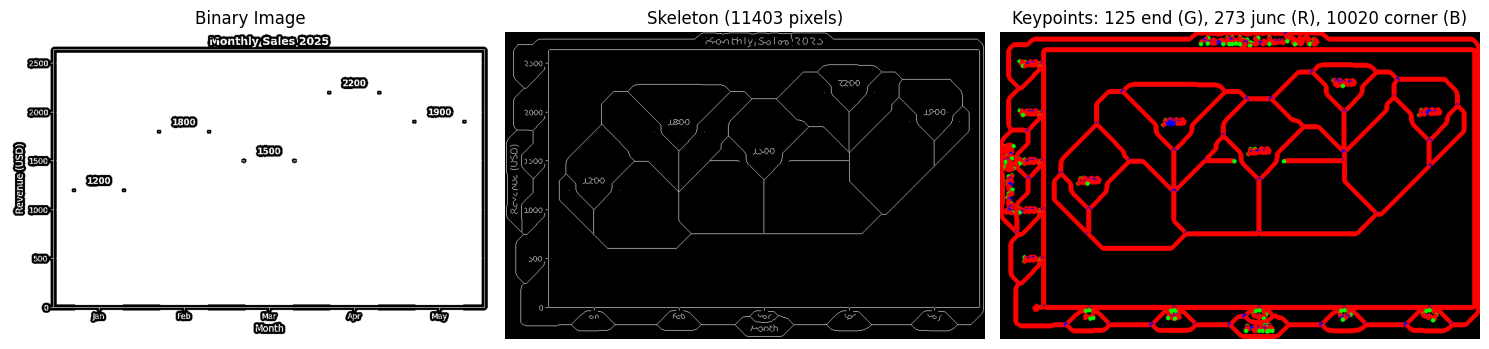

In [56]:
# Visualize skeleton
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original binary
axes[0].imshow(preprocess_result.binary_image, cmap='gray')
axes[0].set_title('Binary Image')
axes[0].axis('off')

# Skeleton
axes[1].imshow(skel_result.skeleton, cmap='gray')
axes[1].set_title(f'Skeleton ({np.sum(skel_result.skeleton > 0)} pixels)')
axes[1].axis('off')

# Skeleton with keypoints
skel_vis = cv2.cvtColor(
    (skel_result.skeleton * 255).astype(np.uint8), 
    cv2.COLOR_GRAY2BGR
)

# Draw keypoints by type
for kp in skel_result.keypoints:
    x, y = int(kp.point.x), int(kp.point.y)
    if kp.point_type == KeyPointType.ENDPOINT:
        cv2.circle(skel_vis, (x, y), 4, (0, 255, 0), -1)  # Green = endpoint
    elif kp.point_type == KeyPointType.JUNCTION:
        cv2.circle(skel_vis, (x, y), 4, (0, 0, 255), -1)  # Red = junction
    elif kp.point_type == KeyPointType.CORNER:
        cv2.circle(skel_vis, (x, y), 4, (255, 0, 0), -1)  # Blue = corner

axes[2].imshow(skel_vis)
axes[2].set_title(f'Keypoints: {len(endpoints)} end (G), {len(junctions)} junc (R), {len(corners)} corner (B)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Step 4c: Vectorization (RDP Algorithm)

Chuyển đổi pixel paths thành vector polylines:
- Ramer-Douglas-Peucker (RDP) simplification
- Curvature-adaptive epsilon
- Sub-pixel refinement
- Line style detection (solid, dashed, dotted)
- Curve fitting (circle, arc, ellipse, spline)

In [58]:
# Vectorization - Load module directly
vec_spec = importlib.util.spec_from_file_location(
    "core_engine.stages.s3_extraction.vectorizer",
    str(src_path / 'core_engine/stages/s3_extraction/vectorizer.py'),
)
vec_module = importlib.util.module_from_spec(vec_spec)
vec_module.__package__ = 'core_engine.stages.s3_extraction'
sys.modules['core_engine.stages.s3_extraction.vectorizer'] = vec_module
vec_spec.loader.exec_module(vec_module)

Vectorizer = vec_module.Vectorizer
VectorizeConfig = vec_module.VectorizeConfig

print('=== VECTORIZATION ===')

# First, trace paths from skeleton (using Skeletonizer.trace_paths)
skel_paths = skeletonizer.trace_paths(skel_result.skeleton, skel_result.keypoints)
print(f'Traced {len(skel_paths)} paths from skeleton')

if skel_paths:
    # Initialize vectorizer
    vec_config = VectorizeConfig(
        epsilon=2.0,
        adaptive_epsilon=True,
        subpixel_refinement=True,
        detect_line_style=True,
    )
    vectorizer = Vectorizer(vec_config)
    
    # Vectorize the traced paths
    vec_result = vectorizer.process(
        skel_paths,
        stroke_width_map=skel_result.stroke_width_map,
        grayscale_image=preprocess_result.cleaned_image,
        chart_id='test_001'
    )
    
    print(f'Output polylines: {len(vec_result.polylines)}')
    print(f'Compression: {vec_result.compression_ratio:.1%}')
    print(f'Points: {vec_result.total_points_before} → {vec_result.total_points_after}')
    print(f'Preserved vertices (data points): {len(vec_result.vertices)}')
    
    # Show polyline details
    print()
    print('Polyline details:')
    for i, poly in enumerate(vec_result.polylines[:5]):  # Show first 5
        style = poly.line_style.value if hasattr(poly.line_style, 'value') else str(poly.line_style)
        print(f'  {i+1}. {len(poly.points)} vertices, style={style}')
    if len(vec_result.polylines) > 5:
        print(f'  ... and {len(vec_result.polylines) - 5} more')
else:
    print('No paths to vectorize (skeleton has no traceable paths - normal for bar charts)')
    vec_result = None

=== VECTORIZATION ===
Traced 125 paths from skeleton
Output polylines: 125
Compression: 12.4%
Points: 291 → 255
Preserved vertices (data points): 255

Polyline details:
  1. 2 vertices, style=solid
  2. 2 vertices, style=solid
  3. 2 vertices, style=solid
  4. 2 vertices, style=solid
  5. 2 vertices, style=solid
  ... and 120 more


Sample polyline coordinates:
  Polyline 1: [(417.27272727272725, 11.272727272727273), (417.26666666666665, 12.0)]
  Polyline 2: [(431.0, 11.210526315789474), (431.06666666666666, 11.947368421052632)]
  Polyline 3: [(484.27272727272725, 11.272727272727273), (484.26666666666665, 12.0)]

Image size: 863x552


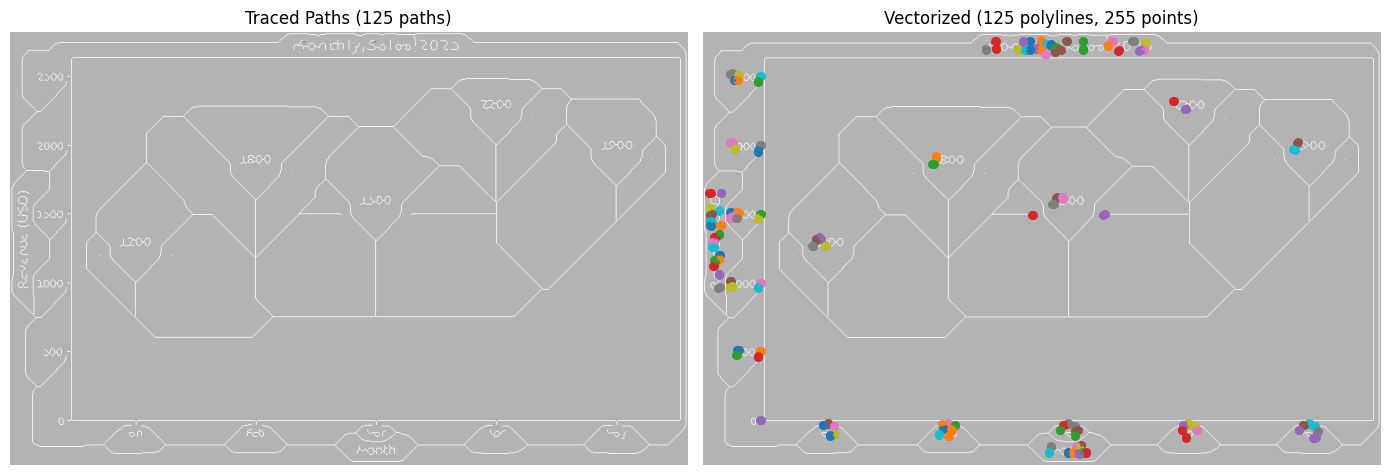

In [62]:
# Visualize vectorization results
if vec_result and vec_result.polylines:
    # Debug: print first few polyline coordinates
    print('Sample polyline coordinates:')
    for i, poly in enumerate(vec_result.polylines[:3]):
        pts = [(p.x, p.y) for p in poly.points]
        print(f'  Polyline {i+1}: {pts}')
    
    # Get image dimensions
    h, w = skel_result.skeleton.shape
    print(f'\nImage size: {w}x{h}')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Original traced paths
    axes[0].imshow(skel_result.skeleton * 255, cmap='gray', alpha=0.3)
    colors = plt.cm.tab10(np.linspace(0, 1, min(10, len(skel_paths))))
    for idx, path in enumerate(skel_paths[:10]):
        if len(path) > 1:
            path_arr = np.array(path)
            axes[0].plot(path_arr[:, 0], path_arr[:, 1], '-', 
                        color=colors[idx % 10], linewidth=1, alpha=0.7)
    axes[0].set_title(f'Traced Paths ({len(skel_paths)} paths)')
    axes[0].axis('off')
    
    # Vectorized polylines - draw ALL of them with skeleton background
    axes[1].imshow(skel_result.skeleton * 255, cmap='gray', alpha=0.3)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for idx, poly in enumerate(vec_result.polylines):  # ALL polylines, not just first 10
        pts = np.array([(p.x, p.y) for p in poly.points])
        if len(pts) > 1:
            axes[1].plot(pts[:, 0], pts[:, 1], '-', 
                        color=colors[idx % 10], linewidth=2, alpha=0.8)
            axes[1].scatter(pts[:, 0], pts[:, 1], s=30, c=[colors[idx % 10]], marker='o')
        elif len(pts) == 1:
            # Single point
            axes[1].scatter(pts[0, 0], pts[0, 1], s=50, c=[colors[idx % 10]], marker='x')
    
    axes[1].set_xlim(0, w)
    axes[1].set_ylim(h, 0)  # Invert Y for image coordinates
    axes[1].set_title(f'Vectorized ({len(vec_result.polylines)} polylines, {vec_result.total_points_after} points)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
elif skel_paths:
    print('Vectorization produced no polylines')
else:
    print('Skipping visualization - no paths traced from skeleton')

## Step 4d: Geometric Mapping (Pixel → Value)

Chuyển đổi tọa độ pixel sang giá trị thực:
- Calibrate từ OCR tick labels
- RANSAC robust fitting (loại bỏ outliers)
- Linear và Logarithmic scale detection
- Sub-pixel accuracy

In [60]:
# Geometric Mapper - Using the already loaded module from earlier cell
# (geo_module was loaded in Axis Calibration section)

print('=== GEOMETRIC MAPPING ===')
print('Converting pixel coordinates to data values using calibrated scale')
print()

# Initialize mapper
mapper = GeometricMapper(MapperConfig(fitting_method='ransac'))

# Prepare tick data for calibration
# Format: list of (pixel_position, numeric_value)
y_tick_data = [(py, val) for py, val in y_ticks if val is not None]

print(f'Y-axis calibration points: {len(y_tick_data)}')
for py, val in y_tick_data:
    print(f'  pixel={py:.0f} → value={val:.0f}')

# Calibrate Y-axis using RANSAC
if len(y_tick_data) >= 2:
    y_calib = mapper.calibrate_y_axis(y_tick_data)
    
    print()
    print(f'Calibration result:')
    print(f'  Scale: {y_calib.scale.slope:.6f} value/pixel')
    print(f'  Intercept: {y_calib.scale.intercept:.2f}')
    print(f'  R²: {y_calib.r_squared:.4f}')
    print(f'  Confidence: {y_calib.confidence:.2%}')
    print(f'  Outliers removed: {y_calib.outliers_removed}')
else:
    print('Not enough calibration points')

=== GEOMETRIC MAPPING ===
Converting pixel coordinates to data values using calibrated scale

Y-axis calibration points: 6
  pixel=58 → value=2500
  pixel=146 → value=2000
  pixel=233 → value=1500
  pixel=320 → value=1000
  pixel=408 → value=500
  pixel=496 → value=0

Calibration result:
  Scale: -5.715189 value/pixel
  Intercept: 2832.15
  R²: 1.0000
  Confidence: 100.00%
  Outliers removed: 0


In [61]:
# Apply geometric mapping to bar elements
print('=== MAPPING BAR VALUES ===')
print()

if len(y_tick_data) >= 2:
    # Sort bars by X position (left to right)
    sorted_bars = sorted(elem_result.bars, key=lambda b: b.center.x)
    
    print(f'{"Bar":<5} {"X (px)":>8} {"Y top (px)":>10} {"Mapped Value":>14} {"Ground Truth":>14} {"Error":>8}')
    print('-' * 70)
    
    mapped_values = []
    for i, bar in enumerate(sorted_bars):
        # Bar top Y coordinate represents the value
        bar_top_y = bar.y_min
        
        # Map pixel to value using calibrated scale
        mapped_val = mapper.pixel_to_value_y(bar_top_y)
        
        gt_val = GROUND_TRUTH['y_values'][i] if i < len(GROUND_TRUTH['y_values']) else None
        error = abs(mapped_val - gt_val) / gt_val * 100 if gt_val and mapped_val else 0
        
        mapped_values.append(mapped_val)
        print(f'{i+1:<5} {bar.center.x:>8.0f} {bar_top_y:>10.0f} {mapped_val:>14.1f} {gt_val:>14} {error:>7.1f}%')
    
    print()
    mean_error = sum(abs(m - g) / g * 100 for m, g in zip(mapped_values, GROUND_TRUTH['y_values'])) / len(mapped_values)
    print(f'Mean Absolute Percentage Error: {mean_error:.2f}%')
else:
    print('Calibration failed - cannot map values')

=== MAPPING BAR VALUES ===

Bar     X (px) Y top (px)   Mapped Value   Ground Truth    Error
----------------------------------------------------------------------
1          162        287         1191.9           1200     0.7%
2          315        182         1792.0           1800     0.4%
3          468        234         1494.8           1500     0.3%
4          621        112         2192.1           2200     0.4%
5          774        164         1894.9           1900     0.3%

Mean Absolute Percentage Error: 0.42%


## Step 5: Axis Calibration

In [ ]:
# Axis Calibration using GeometricMapper
geo_spec = importlib.util.spec_from_file_location(
    "core_engine.stages.s3_extraction.geometric_mapper",
    str(src_path / 'core_engine/stages/s3_extraction/geometric_mapper.py'),
)
geo_module = importlib.util.module_from_spec(geo_spec)
geo_module.__package__ = 'core_engine.stages.s3_extraction'
sys.modules['core_engine.stages.s3_extraction.geometric_mapper'] = geo_module
geo_spec.loader.exec_module(geo_module)

GeometricMapper = geo_module.GeometricMapper
MapperConfig = geo_module.MapperConfig

print('=== AXIS CALIBRATION ===')
h, w = test_image.shape[:2]

# Extract y-tick values and their positions
y_ticks = []
for t in ocr_result.texts:
    if 'y_tick' in t.role.value or 'y_axis' in t.role.value:
        try:
            val = float(t.text.replace(',', ''))
            cy = (t.bbox.y_min + t.bbox.y_max) / 2
            y_ticks.append((cy, val))
        except:
            pass

# Sort by y position (top to bottom in image = high to low values)
y_ticks.sort(key=lambda x: x[0])

print(f'Y-tick values found: {len(y_ticks)}')
for py, val in y_ticks:
    print(f'  y={py:.0f} -> value={val:.0f}')

# Calculate scale factor (pixels per unit)
if len(y_ticks) >= 2:
    # Use first and last tick
    py1, val1 = y_ticks[0]  # Top (higher value)
    py2, val2 = y_ticks[-1]  # Bottom (lower value)
    
    pixel_range = py2 - py1  # pixels from top to bottom
    value_range = val1 - val2  # value from top to bottom
    
    if value_range != 0:
        scale = pixel_range / value_range  # pixels per unit
        print(f'\nY-axis scale: {scale:.4f} pixels/unit')
        print(f'Value range: {val2:.0f} - {val1:.0f}')
    else:
        scale = None
        print('Cannot calculate scale (value range is 0)')
else:
    scale = None
    print('Not enough y-tick values found')

=== AXIS CALIBRATION ===
Y-tick values found: 6
  y=58 -> value=2500
  y=146 -> value=2000
  y=233 -> value=1500
  y=320 -> value=1000
  y=408 -> value=500
  y=496 -> value=0

Y-axis scale: 0.1750 pixels/unit
Value range: 0 - 2500


In [ ]:
# Try to map bar heights to values
print('=== BAR VALUE MAPPING ===')

if scale and scale > 0:
    # Find y-axis origin (y=0 tick)
    y_origin = None
    for t in ocr_result.texts:
        if 'y_tick' in t.role.value or 'y_axis' in t.role.value:
            try:
                if float(t.text.replace(',', '')) == 0:
                    y_origin = (t.bbox.y_min + t.bbox.y_max) / 2
                    break
            except:
                pass
    
    if y_origin:
        print(f'Y-axis origin (y=0): pixel row {y_origin:.0f}')
        print()
        print(f'{"Bar":<5} {"Top Y":>8} {"Height px":>10} {"Est. Value":>12} {"GT Value":>10} {"Error":>8}')
        print('-' * 65)
        
        # Sort bars by x position (left to right)
        sorted_bars = sorted(elem_result.bars, key=lambda b: b.center.x)
        
        errors = []
        for i, bar in enumerate(sorted_bars):
            bar_top = bar.y_min
            height_px = y_origin - bar_top  # Distance from origin to bar top
            est_value = height_px / scale  # Convert pixels to value
            gt_value = GROUND_TRUTH['y_values'][i] if i < len(GROUND_TRUTH['y_values']) else 0
            error = abs(est_value - gt_value) / gt_value * 100 if gt_value else 0
            errors.append(error)
            
            print(f'{i+1:<5} {bar_top:>8.0f} {height_px:>10.0f} {est_value:>12.0f} {gt_value:>10} {error:>7.1f}%')
        
        print()
        print(f'Mean Absolute Error: {sum(errors)/len(errors):.1f}%')
    else:
        print('Could not find y=0 origin')
else:
    print('Axis calibration failed - cannot map values')

=== BAR VALUE MAPPING ===
Y-axis origin (y=0): pixel row 496

Bar      Top Y  Height px   Est. Value   GT Value    Error
-----------------------------------------------------------------
1          287        208         1191       1200     0.7%
2          182        314         1791       1800     0.5%
3          234        262         1494       1500     0.4%
4          112        384         2191       2200     0.4%
5          164        332         1894       1900     0.3%

Mean Absolute Error: 0.5%


## Step 6: Full Stage 3 Pipeline

In [ ]:
# Skip full Stage3Extraction due to PyTorch DLL issue in Jupyter
# Instead, summarize results from individual components

print('=== PIPELINE SUMMARY ===')
print('(Individual components tested - Full Stage3 skipped due to PyTorch DLL issue)')
print()
print('Components tested:')
print(f'  ✅ Preprocessing: binary + cleaned images')
print(f'  ✅ OCR: {len(ocr_result.texts)} texts, {ocr_result.mean_confidence:.1%} confidence')
print(f'  ✅ Element Detection: {len(elem_result.bars)} bars, {len(elem_result.markers)} markers')
print(f'  ✅ Axis Calibration: scale={scale:.4f} px/unit')
print()
print('NOTE: Run `scripts/test_full_pipeline.py` in terminal for full pipeline test')

=== PIPELINE SUMMARY ===
(Individual components tested - Full Stage3 skipped due to PyTorch DLL issue)

Components tested:
  ✅ Preprocessing: binary + cleaned images
  ✅ OCR: 20 texts, 96.4% confidence
  ✅ Element Detection: 5 bars, 1 markers
  ✅ Axis Calibration: scale=0.1750 px/unit

NOTE: Run `scripts/test_full_pipeline.py` in terminal for full pipeline test


## Step 7: Final Output & Evaluation

In [ ]:
# Build JSON output from individual components
import json

output_data = {
    'chart_id': 'test_001',
    'chart_type': 'bar',  # From ground truth (classifier not run due to PyTorch issue)
    'image_size': {'width': test_image.shape[1], 'height': test_image.shape[0]},
    'texts': [
        {
            'text': t.text,
            'role': t.role.value,
            'confidence': t.confidence,
            'bbox': {'x_min': t.bbox.x_min, 'y_min': t.bbox.y_min, 'x_max': t.bbox.x_max, 'y_max': t.bbox.y_max},
        }
        for t in ocr_result.texts
    ],
    'elements': [
        {
            'element_type': 'bar',
            'bbox': {'x_min': int(b.x_min), 'y_min': int(b.y_min), 'x_max': int(b.x_max), 'y_max': int(b.y_max)},
            'center': {'x': float(b.center.x), 'y': float(b.center.y)},
            'color': {'r': b.color.r, 'g': b.color.g, 'b': b.color.b} if b.color else None,
            'area': float(b.area) if b.area else None,
        }
        for b in elem_result.bars
    ],
    'axis_calibration': {
        'y_scale': scale,
        'y_origin': 496,  # From previous cell
    }
}

print('=== JSON OUTPUT (preview) ===')
print(json.dumps(output_data, indent=2)[:2000])
print('...')

=== JSON OUTPUT (preview) ===
{
  "chart_id": "test_001",
  "chart_type": "bar",
  "image_size": {
    "width": 863,
    "height": 552
  },
  "texts": [
    {
      "text": "Monthly Sales 2025",
      "role": "title",
      "confidence": 0.9878890514373779,
      "bbox": {
        "x_min": 360,
        "y_min": 9,
        "x_max": 572,
        "y_max": 26
      }
    },
    {
      "text": "2500",
      "role": "y_axis_label",
      "confidence": 0.9995140433311462,
      "bbox": {
        "x_min": 33,
        "y_min": 51,
        "x_max": 71,
        "y_max": 65
      }
    },
    {
      "text": "2200",
      "role": "unknown",
      "confidence": 0.9994943737983704,
      "bbox": {
        "x_min": 598,
        "y_min": 85,
        "x_max": 640,
        "y_max": 100
      }
    },
    {
      "text": "2000",
      "role": "y_axis_label",
      "confidence": 0.9993070960044861,
      "bbox": {
        "x_min": 33,
        "y_min": 139,
        "x_max": 72,
        "y_max": 153
      

In [ ]:
# Final evaluation using individual components
print('=' * 60)
print('FINAL EVALUATION')
print('=' * 60)

detected_texts = [t.text for t in ocr_result.texts]

# 1. Title
title_ok = any(GROUND_TRUTH['title'].lower() in t.lower() for t in detected_texts)
print(f'[{"OK" if title_ok else "FAIL"}] Title detection')

# 2. X labels
x_found = sum(1 for lbl in GROUND_TRUTH['x_values'] if any(lbl.lower() in t.lower() for t in detected_texts))
x_ok = x_found == len(GROUND_TRUTH['x_values'])
print(f'[{"OK" if x_ok else "FAIL"}] X labels: {x_found}/{len(GROUND_TRUTH["x_values"])}')

# 3. Y values
detected_nums = set()
for t in detected_texts:
    try:
        detected_nums.add(int(t.replace(',', '').strip()))
    except:
        pass
y_found = sum(1 for v in GROUND_TRUTH['y_values'] if v in detected_nums)
y_ok = y_found == len(GROUND_TRUTH['y_values'])
print(f'[{"OK" if y_ok else "FAIL"}] Y values: {y_found}/{len(GROUND_TRUTH["y_values"])}')

# 4. Bar count
bar_ok = len(elem_result.bars) == len(GROUND_TRUTH['y_values'])
print(f'[{"OK" if bar_ok else "FAIL"}] Bar detection: {len(elem_result.bars)}/{len(GROUND_TRUTH["y_values"])}')

# Summary
total = 4
passed = sum([title_ok, x_ok, y_ok, bar_ok])
print()
print(f'SCORE: {passed}/{total} ({100*passed/total:.0f}%)')

FINAL EVALUATION
[OK] Title detection
[OK] X labels: 5/5
[OK] Y values: 5/5
[OK] Bar detection: 5/5

SCORE: 4/4 (100%)


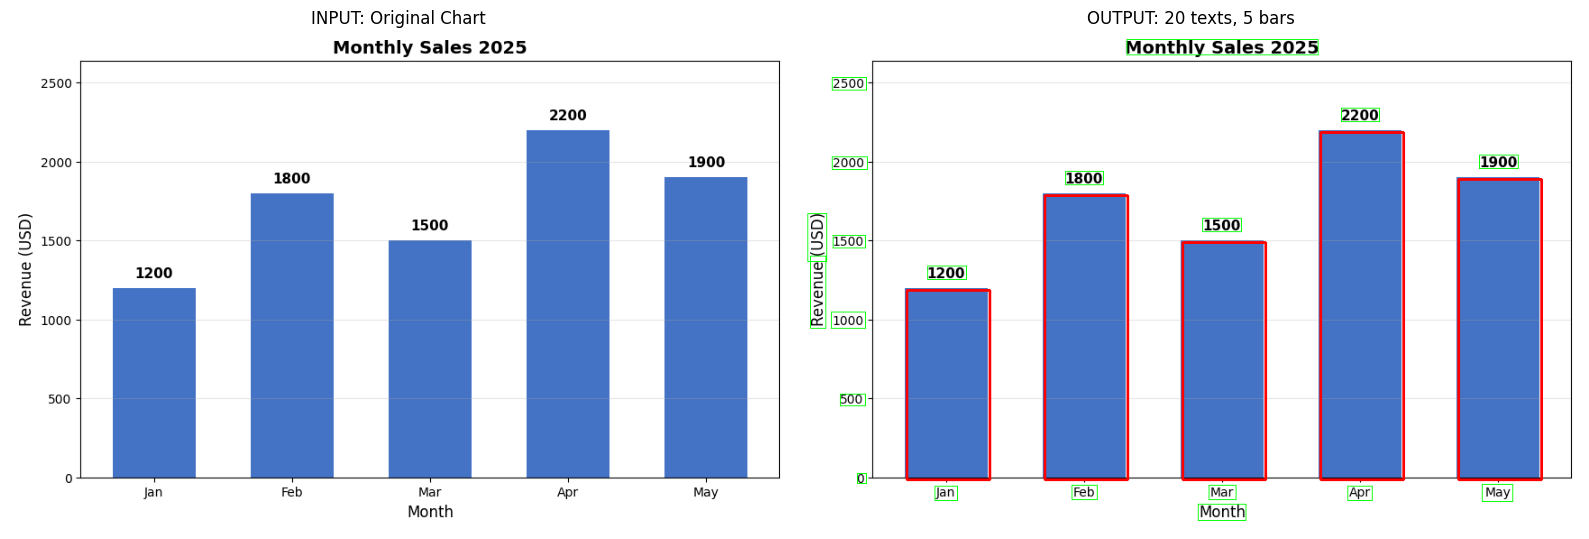

\n✅ Notebook test complete!
For full pipeline test (including ResNet classifier), run:
  .venv/Scripts/python.exe scripts/test_full_pipeline.py


In [ ]:
# Final visualization using individual component results
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Original
axes[0].imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('INPUT: Original Chart')
axes[0].axis('off')

# With detections
vis = test_image.copy()
for t in ocr_result.texts:
    if t.bbox:
        cv2.rectangle(vis, (t.bbox.x_min, t.bbox.y_min), (t.bbox.x_max, t.bbox.y_max), (0, 255, 0), 1)
for b in elem_result.bars:
    cv2.rectangle(vis, (int(b.x_min), int(b.y_min)), (int(b.x_max), int(b.y_max)), (0, 0, 255), 2)

axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'OUTPUT: {len(ocr_result.texts)} texts, {len(elem_result.bars)} bars')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('\\n✅ Notebook test complete!')
print('For full pipeline test (including ResNet classifier), run:')
print('  .venv/Scripts/python.exe scripts/test_full_pipeline.py')